In [3]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
TRAIN_DIR = '../dataset/Train'
TEST_DIR  = '../dataset/Test'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
CLASSES    = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Config set!")
print(f"Train: {TRAIN_DIR}")
print(f"Test : {TEST_DIR}")

Config set!
Train: ../dataset/Train
Test : ../dataset/Test


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples : {train_generator.samples}")
print(f"Val samples   : {val_generator.samples}")
print(f"Test samples  : {test_generator.samples}")
print(f"Class indices : {train_generator.class_indices}")

Found 7722 images belonging to 4 classes.
Found 1928 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.
Train samples : 7722
Val samples   : 1928
Test samples  : 2414
Class indices : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_generator.classes
)

CLASS_WEIGHT = dict(enumerate(class_weights))
print("Class Weights:")
for k, v in CLASS_WEIGHT.items():
    print(f"  {CLASSES[k]}: {v:.4f}")

Class Weights:
  glioma: 0.7994
  meningioma: 1.1050
  notumor: 1.2407
  pituitary: 0.9633


In [7]:
def build_model(num_classes=4):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

model, base_model = build_model()
print("ResNet50 model built!")
print(f"Total layers: {len(model.layers)}")

94765736/94765736 [==============================] - 23s 0us/step
ResNet50 model built!
Total layers: 182


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled!")

Model compiled!


In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '../models/best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
print("Callbacks ready!")

Callbacks ready!


In [10]:
print("=" * 50)
print("PHASE 1: Training with frozen base model")
print("=" * 50)

history1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1
)

PHASE 1: Training with frozen base model
Epoch 1/15
242/242 [==============================] - ETA: 0s - loss: 1.0508 - accuracy: 0.5588
Epoch 1: val_accuracy improved from -inf to 0.57936, saving model to ../models\best_model_phase1.keras
242/242 [==============================] - 81s 263ms/step - loss: 1.0508 - accuracy: 0.5588 - val_loss: 1.1621 - val_accuracy: 0.5794 - lr: 0.0010
Epoch 2/15
242/242 [==============================] - ETA: 0s - loss: 0.8938 - accuracy: 0.6242
Epoch 2: val_accuracy improved from 0.57936 to 0.68568, saving model to ../models\best_model_phase1.keras
242/242 [==============================] - 64s 266ms/step - loss: 0.8938 - accuracy: 0.6242 - val_loss: 0.9305 - val_accuracy: 0.6857 - lr: 0.0010
Epoch 3/15
242/242 [==============================] - ETA: 0s - loss: 0.8428 - accuracy: 0.6476
Epoch 3: val_accuracy did not improve from 0.68568
242/242 [==============================] - 70s 289ms/step - loss: 0.8428 - accuracy: 0.6476 - val_loss: 0.8058 - val_

In [11]:
print("=" * 50)
print("PHASE 2: Fine-tuning top layers")
print("=" * 50)

from tensorflow.keras.models import load_model

model = load_model('../models/best_model_phase1.keras')

for layer in model.layers:
    layer.trainable = True

for layer in model.layers[:-20]:
    layer.trainable = False

print(f"Trainable layers: {sum([l.trainable for l in model.layers])}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '../models/best_model_finetuned.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

history2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks_ft,
    verbose=1
)

PHASE 2: Fine-tuning top layers
Trainable layers: 20
Epoch 1/20
242/242 [==============================] - ETA: 0s - loss: 1.0439 - accuracy: 0.5918
Epoch 1: val_accuracy improved from -inf to 0.28890, saving model to ../models\best_model_finetuned.keras
242/242 [==============================] - 73s 282ms/step - loss: 1.0439 - accuracy: 0.5918 - val_loss: 2.4590 - val_accuracy: 0.2889 - lr: 1.0000e-05
Epoch 2/20
242/242 [==============================] - ETA: 0s - loss: 0.8625 - accuracy: 0.6356
Epoch 2: val_accuracy improved from 0.28890 to 0.71473, saving model to ../models\best_model_finetuned.keras
242/242 [==============================] - 80s 328ms/step - loss: 0.8625 - accuracy: 0.6356 - val_loss: 0.7411 - val_accuracy: 0.7147 - lr: 1.0000e-05
Epoch 3/20
242/242 [==============================] - ETA: 0s - loss: 0.8071 - accuracy: 0.6664
Epoch 3: val_accuracy improved from 0.71473 to 0.72199, saving model to ../models\best_model_finetuned.keras
242/242 [========================

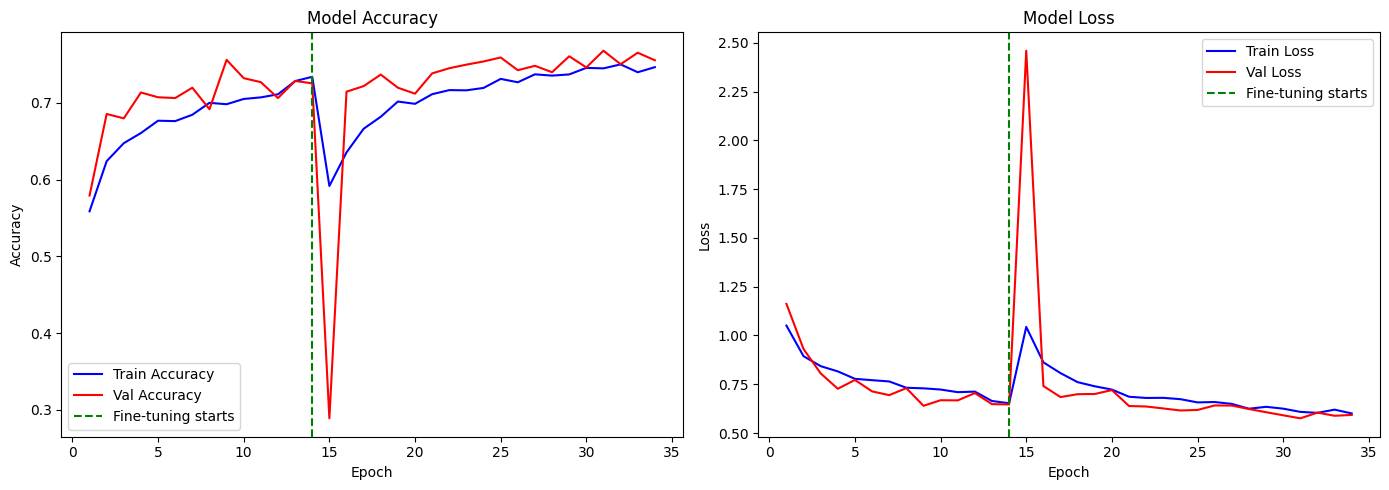

In [12]:
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    phase2_start = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, acc, 'b-', label='Train Accuracy')
    axes[0].plot(epochs, val_acc, 'r-', label='Val Accuracy')
    axes[0].axvline(x=phase2_start, color='green', linestyle='--', label='Fine-tuning starts')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epochs, loss, 'b-', label='Train Loss')
    axes[1].plot(epochs, val_loss, 'r-', label='Val Loss')
    axes[1].axvline(x=phase2_start, color='green', linestyle='--', label='Fine-tuning starts')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

In [13]:
model.save('../models/final_model.keras')

class_indices = train_generator.class_indices
with open('../models/class_indices.json', 'w') as f:
    json.dump(class_indices, f)

print("Final model saved!")
print("Class indices saved!")
print(class_indices)

Final model saved!
Class indices saved!
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
